# EDA 02 — daily visit counts by reproductive status

Wide day-resolved activity matrix: `data/processed/daily_counts/daily_counts_sit{10,30,60,120,300,600}s.csv`
(built by `src/build_daily_counts.py`).

One chapter per logger **sit** threshold — the gap in seconds that defines an independent
visit event. Finer thresholds keep more events (a single emergence can register several times
as the bat hovers at the entrance); coarser thresholds collapse a visit to ~one event.

Each chapter shows the **average number of visits per bat-day**, split by reproductive status:

* **Lactating** — `Reproduction State == Yes`
* **Not lactating** — `Reproduction State == No`
* **Unlabelled** — blank `Reproduction State` (or no row in the label table that year)

Band = **95 % CI of the mean** (`1.96 * SEM`).


## Setup

In [1]:
%matplotlib inline
from pathlib import Path
import datetime as dt

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DC = REPO / "data" / "processed" / "daily_counts"

SITS = [10, 30, 60, 120, 300, 600]
DAYS = [f"Day{i}" for i in range(1, 366)]

# Day index -> calendar date. 29 Feb is dropped by the builder, so a non-leap
# reference year maps DayN to the right calendar date for every year.
REF = [dt.date(2023, 1, 1) + dt.timedelta(days=i) for i in range(365)]

# logger coverage window (see the coverage cell at the bottom)
WIN = (dt.date(2023, 4, 25), dt.date(2023, 9, 20))

GROUPS = [
    ("Lactating",     "Yes", "tab:red"),
    ("Not lactating", "No",  "tab:blue"),
    ("Unlabelled",    "",    "tab:gray"),
]


def load(sit):
    df = pd.read_csv(DC / f"daily_counts_sit{sit}s.csv")
    df["Lactating"] = df["Lactating"].fillna("")
    return df


def day_stats(df, label):
    """Per-day mean and 95% CI of the mean for one status group."""
    X = df.loc[df["Lactating"] == label, DAYS].to_numpy(dtype=float)
    n = len(X)
    if n == 0:
        return n, np.zeros(365), np.zeros(365)
    mean = X.mean(axis=0)
    ci = 1.96 * X.std(axis=0, ddof=1) / np.sqrt(n) if n > 1 else np.zeros(365)
    return n, mean, ci


def month_axis(ax):
    ax.set_xticks([dt.date(2023, m, 1) for m in range(1, 13)])
    ax.set_xticklabels(["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                        "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
    ax.set_xlim(dt.date(2023, 1, 1), dt.date(2023, 12, 31))


def plot_sit(sit):
    df = load(sit)
    fig, ax = plt.subplots(figsize=(12.5, 4.4))

    # shade the months the loggers were not running
    ax.axvspan(dt.date(2023, 1, 1), WIN[0], color="k", alpha=0.04, lw=0)
    ax.axvspan(WIN[1], dt.date(2023, 12, 31), color="k", alpha=0.04, lw=0)

    stats = {}
    for name, label, color in GROUPS:
        n, mean, ci = day_stats(df, label)
        stats[name] = (n, mean, ci)
        ax.plot(REF, mean, color=color, lw=1.7, label=f"{name} (n={n} bat-years)")
        ax.fill_between(REF, np.maximum(mean - ci, 0), mean + ci,
                        color=color, alpha=0.18, lw=0)

    month_axis(ax)
    ax.set_ylabel("visits per bat-day\n(mean ± 95% CI)")
    ax.set_title(f"Average visits per bat-day — sit = {sit} s   "
                 f"(shaded = outside logger window)", fontsize=11)
    ax.legend(frameon=False, ncol=3, loc="upper left", fontsize=9)
    ax.grid(alpha=0.15, lw=0.6)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()

    for name, (n, mean, ci) in stats.items():
        i = int(np.argmax(mean))
        print(f"  {name:<14} n={n:<5} peak mean {mean[i]:6.2f} ± {ci[i]:.2f} on {REF[i]:%b %d}"
              f"   season total events={mean.sum() * n:,.0f}")
    return df, stats


## How to read this

* **x** — calendar day (29 Feb removed, so the axis is identical for every year and every bat stacks onto the same day).
* **y** — mean number of *independent visit events* per bat-day, averaged over the bat-years in that group.
  A bat only appears in a year in which it was detected, and the loggers only ran Apr–Sep (shaded),
  so the flat zero stretch outside the window is *absence of logging*, not absence of bats.
* **band** — 95 % CI of the mean across bat-years (`1.96·SEM`). It is a confidence band for the
  average bat, not a spread band: individual bat-nights are far more variable than the band suggests.
* The three groups are **different animals**, not a within-bat contrast: a bat is either lactating
  or not in a given year.


## Chapter — sit = 10 s (near-raw)

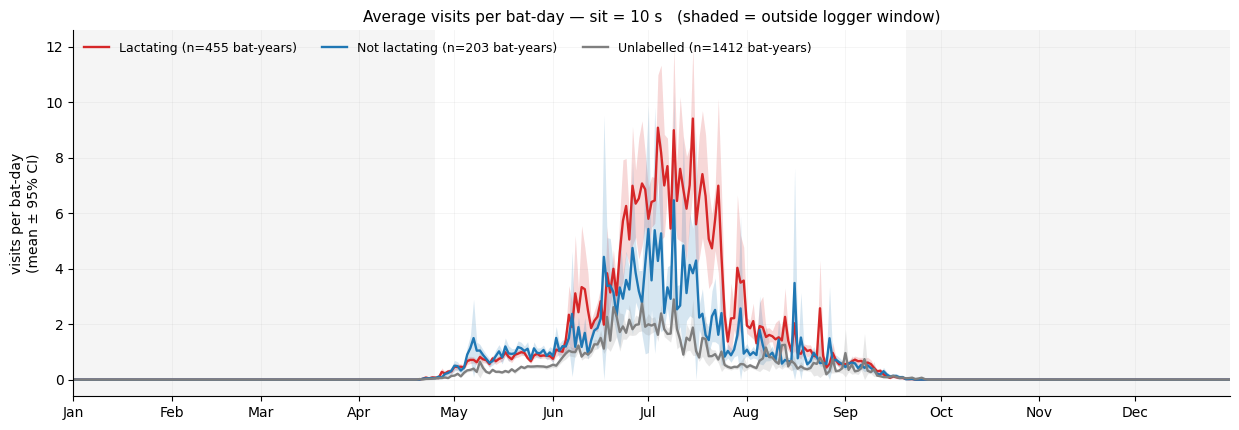

  Lactating      n=455   peak mean   9.41 ± 2.58 on Jul 15   season total events=163,169
  Not lactating  n=203   peak mean   6.46 ± 3.90 on Jul 09   season total events=46,183
  Unlabelled     n=1412  peak mean   2.89 ± 0.97 on Jul 09   season total events=167,273


In [2]:
df_10, stats_10 = plot_sit(10)

## Chapter — sit = 30 s

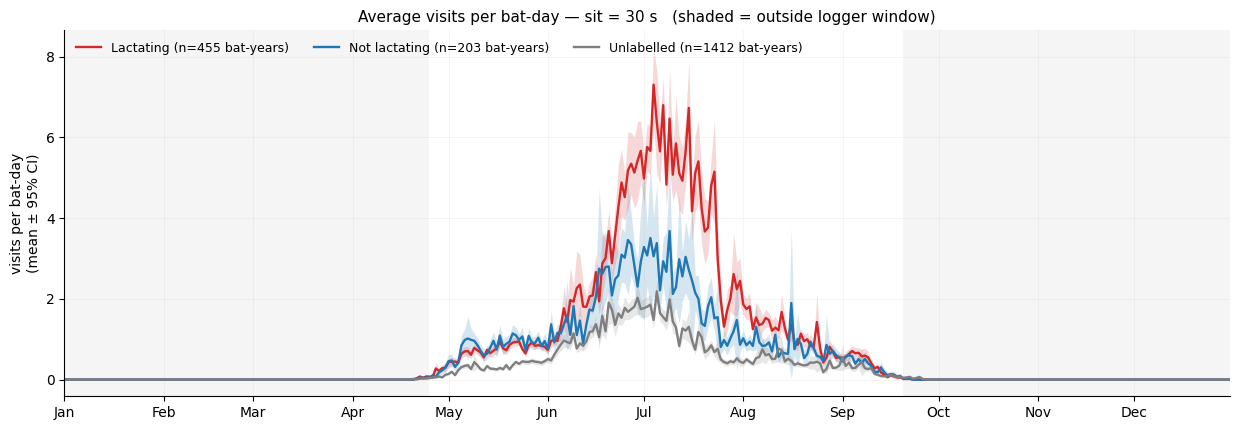

  Lactating      n=455   peak mean   7.30 ± 0.93 on Jul 04   season total events=133,244
  Not lactating  n=203   peak mean   3.68 ± 1.60 on Jul 09   season total events=37,849
  Unlabelled     n=1412  peak mean   2.19 ± 0.28 on Jul 05   season total events=142,298


In [3]:
df_30, stats_30 = plot_sit(30)

## Chapter — sit = 60 s

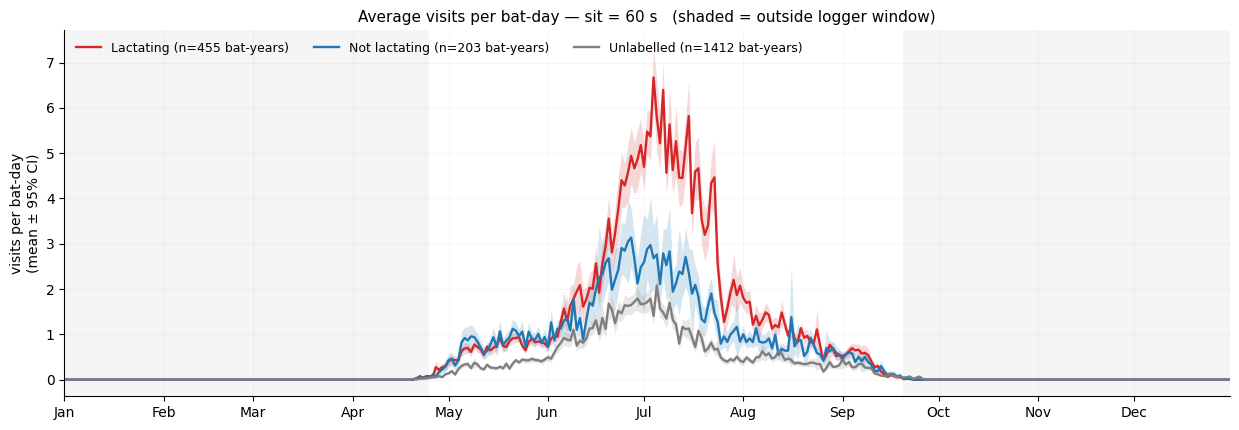

  Lactating      n=455   peak mean   6.67 ± 0.67 on Jul 04   season total events=122,726
  Not lactating  n=203   peak mean   3.14 ± 0.66 on Jun 27   season total events=34,931
  Unlabelled     n=1412  peak mean   2.08 ± 0.26 on Jul 05   season total events=132,940


In [4]:
df_60, stats_60 = plot_sit(60)

## Chapter — sit = 120 s

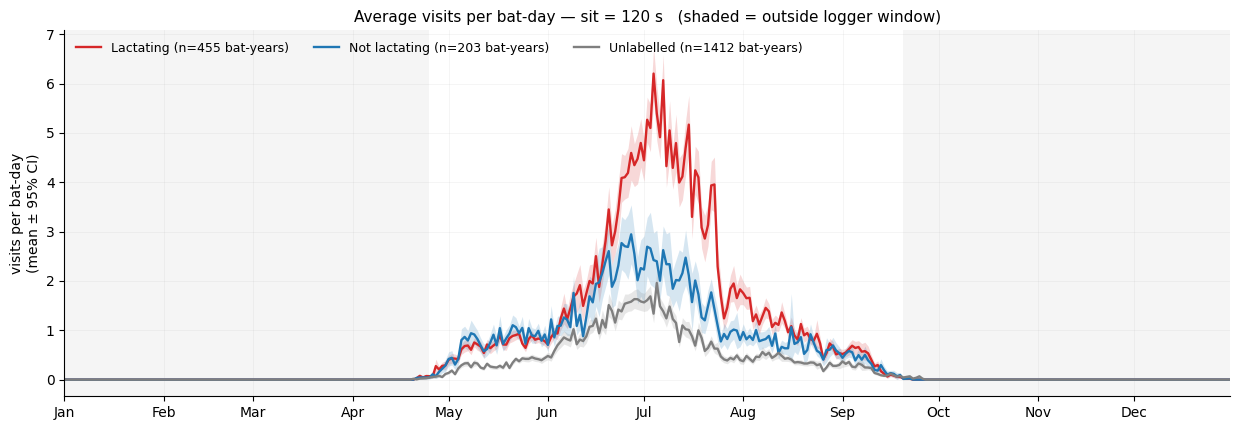

  Lactating      n=455   peak mean   6.20 ± 0.54 on Jul 04   season total events=115,120
  Not lactating  n=203   peak mean   2.95 ± 0.60 on Jun 27   season total events=32,921
  Unlabelled     n=1412  peak mean   1.96 ± 0.25 on Jul 05   season total events=125,199


In [5]:
df_120, stats_120 = plot_sit(120)

## Chapter — sit = 300 s

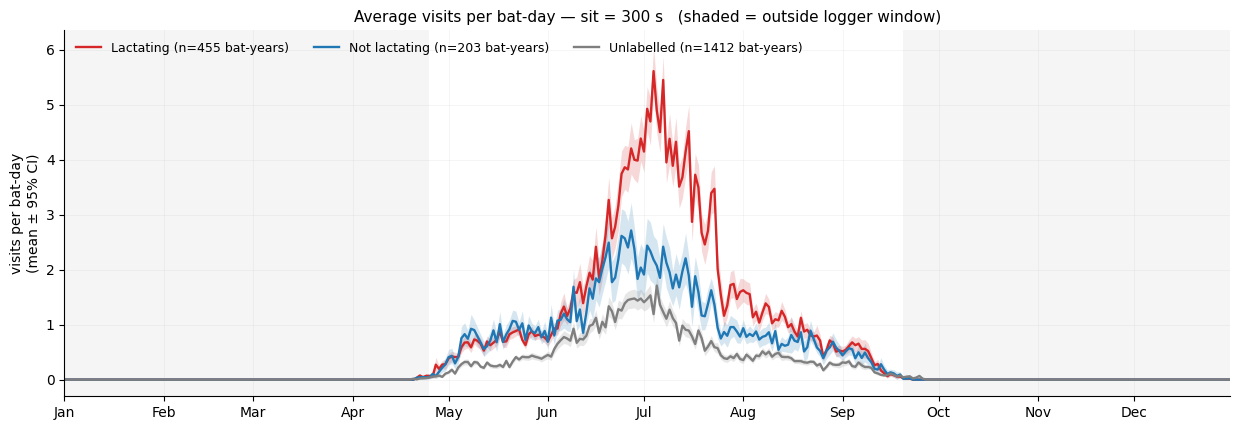

  Lactating      n=455   peak mean   5.61 ± 0.44 on Jul 04   season total events=106,244
  Not lactating  n=203   peak mean   2.71 ± 0.50 on Jun 27   season total events=30,824
  Unlabelled     n=1412  peak mean   1.71 ± 0.20 on Jul 05   season total events=115,156


In [6]:
df_300, stats_300 = plot_sit(300)

## Chapter — sit = 600 s (coarsest, ~1 event per emergence)

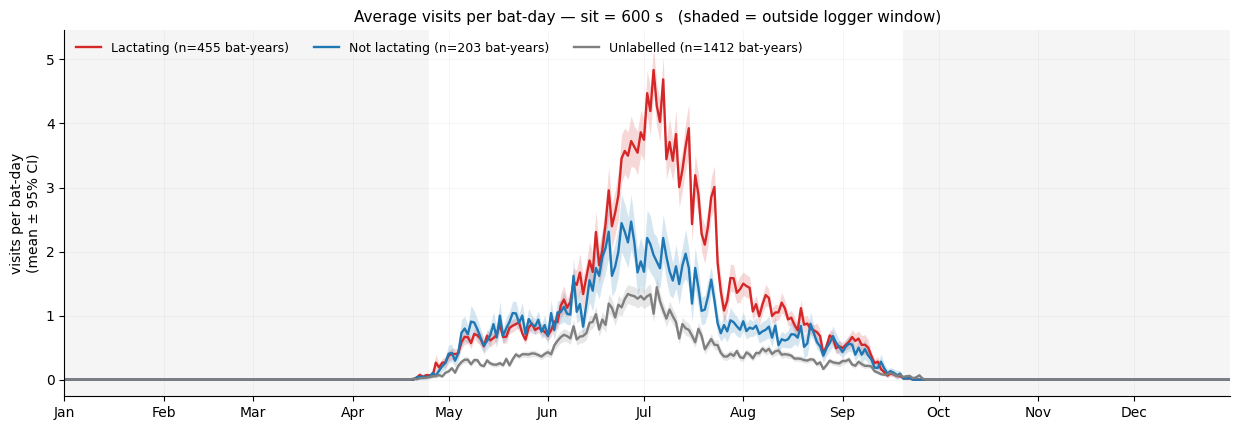

  Lactating      n=455   peak mean   4.84 ± 0.36 on Jul 04   season total events=97,118
  Not lactating  n=203   peak mean   2.47 ± 0.42 on Jun 27   season total events=29,042
  Unlabelled     n=1412  peak mean   1.44 ± 0.17 on Jul 05   season total events=105,584


In [7]:
df_600, stats_600 = plot_sit(600)

## Summary — does the sit threshold change the picture?

Peak daily mean and group sizes per threshold.


In [8]:
rows = []
for sit in SITS:
    for name, label, _ in GROUPS:
        n, mean, ci = day_stats(load(sit), label)
        i = int(np.argmax(mean))
        rows.append({"sit": sit, "group": name, "n_bat_years": n,
                     "peak_mean": round(float(mean[i]), 3),
                     "peak_day": f"{REF[i]:%b %d}",
                     "total_events": int(mean.sum() * n)})
summary = pd.DataFrame(rows)
display(summary.pivot(index="sit", columns="group",
                      values=["n_bat_years", "peak_mean", "total_events"]))


n_bat_years                          peak_mean                           \
group   Lactating Not lactating Unlabelled Lactating Not lactating Unlabelled   
sit                                                                             
10          455.0         203.0     1412.0     9.407         6.463      2.890   
30          455.0         203.0     1412.0     7.303         3.680      2.186   
60          455.0         203.0     1412.0     6.670         3.138      2.079   
120         455.0         203.0     1412.0     6.204         2.946      1.960   
300         455.0         203.0     1412.0     5.613         2.714      1.711   
600         455.0         203.0     1412.0     4.835         2.468      1.443   

      total_events                           
group    Lactating Not lactating Unlabelled  
sit                                          
10        163169.0       46182.0   167273.0  
30        133244.0       37849.0   142298.0  
60        122726.0       34931.0   132940.0  
120       115120.0       32921.0   125199.0  
300       106243.0       30824.0   115156.0  
600        97118.0       29041.0   105584.0

### Same day, all thresholds — does the sit choice matter?

Peak values are noisy, so compare every threshold on **one fixed day** (Jul 5, the middle of
the season) and ask how cleanly the lactating / not-lactating means separate.
`z` is the two-sample separation at that day; `chatter` is the inflation in total events
relative to sit600s.


In [9]:
DAY_REF = 186  # 0-based index -> Jul 5
out = []
for sit in SITS:
    df = load(sit)
    X = df[DAYS].to_numpy(dtype=float)
    res = {}
    for label in ["Yes", "No", ""]:
        v = X[df["Lactating"].to_numpy() == label]
        res[label] = dict(n=len(v), mean=v.mean(0)[DAY_REF],
                          sem=v.std(0, ddof=1)[DAY_REF] / np.sqrt(len(v)),
                          events=v.sum())
    ml, sl = res["Yes"]["mean"], res["Yes"]["sem"]
    mn, sn = res["No"]["mean"], res["No"]["sem"]
    out.append(dict(sit=sit, lact=round(ml, 2), not_lact=round(mn, 2),
                    ratio=round(ml / mn, 2),
                    z=round((ml - mn) / np.sqrt(sl**2 + sn**2), 1),
                    chatter_lact=round(res["Yes"]["events"] / 97118, 2),
                    chatter_notlact=round(res["No"]["events"] / 29042, 2)))
display(pd.DataFrame(out).set_index("sit"))
print("Reference day:", REF[DAY_REF].strftime("%b %d"))


,lact,not_lact,ratio,z,chatter_lact,chatter_notlact
sit,,,,,,
10,7.00,2.40,2.91,4.7,1.68,1.59
30,5.65,2.21,2.55,7.3,1.37,1.30
60,5.22,2.11,2.47,8.7,1.26,1.20
120,4.91,2.00,2.45,9.6,1.19,1.13
300,4.50,1.85,2.43,10.2,1.09,1.06
600,4.02,1.74,2.31,10.1,1.00,1.00


Reference day: Jul 06


In [10]:
# logger coverage: days with at least one detection anywhere, pooled over years
for sit in [10, 600]:
    df = load(sit)
    any_act = (df[DAYS].to_numpy(dtype=float) > 0).any(axis=0)
    idx = np.flatnonzero(any_act)
    print(f"sit{sit}s: days with >=1 detection anywhere: {len(idx)}/365, "
          f"first {REF[idx[0]]:%b %d}, last {REF[idx[-1]]:%b %d}")


sit10s: days with >=1 detection anywhere: 160/365, first Apr 20, last Sep 26
sit600s: days with >=1 detection anywhere: 160/365, first Apr 20, last Sep 26
